# 💼 Data Analyst Jobs — Market Analysis & Salary Prediction
### Unlocking Job Market Trends from 2000+ Real Job Postings
---
**Dataset:** 2,253 job listings × 16 features | Salary, Location, Industry, Skills & Company metadata

## Step 1 — Problem Definition

**Objectives:**
- Analyze trends in data analyst job postings across industries and locations
- Predict salary ranges based on job attributes (rating, skills, company size, etc.)
- Provide actionable insights on in-demand skills, top sectors, and company ratings

**Key Columns:**
`Job Title`, `Salary Estimate`, `Job Description`, `Rating`, `Company Name`, `Location`, `Size`, `Founded`, `Industry`, `Sector`, `Revenue`, `Easy Apply`

## Step 2 — Data Collection & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120})

# Load dataset
data = pd.read_csv("/mnt/user-data/uploads/DataAnalyst.csv")

print(f"Dataset shape: {data.shape[0]} rows × {data.shape[1]} columns")
print("\nColumn names:")
print(data.columns.tolist())

Dataset shape: 2253 rows × 16 columns

Column names:
['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Easy Apply']


In [2]:
print("--- First 5 Rows ---")
data.head()

--- First 5 Rows ---


,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [3]:
print("--- Dataset Info ---")
data.info()

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2253 non-null   int64  
 1   Job Title          2253 non-null   str    
 2   Salary Estimate    2253 non-null   str    
 3   Job Description    2253 non-null   str    
 4   Rating             2253 non-null   float64
 5   Company Name       2252 non-null   str    
 6   Location           2253 non-null   str    
 7   Headquarters       2253 non-null   str    
 8   Size               2253 non-null   str    
 9   Founded            2253 non-null   int64  
 10  Type of ownership  2253 non-null   str    
 11  Industry           2253 non-null   str    
 12  Sector             2253 non-null   str    
 13  Revenue            2253 non-null   str    
 14  Competitors        2253 non-null   str    
 15  Easy Apply         2253 non-null   str    
dtypes: float64(1),

## Step 3 — Exploratory Data Analysis (EDA)

### Step 3.1 — Overview & Distributions

In [4]:
# Duplicates
print(f"Duplicate rows: {data.duplicated().sum()}")
print(f"Total rows: {len(data)}")

# General statistics for numerical columns
print("\n--- Numerical Summary ---")
data.describe(include='all').T.head(20)

Duplicate rows: 0
Total rows: 2253

--- Numerical Summary ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,2253.0,NaN,NaN,NaN,1126.0,650.5294,0.0,563.0,1126.0,1689.0,2252.0
Job Title,2253,1272,Data Analyst,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary Estimate,2253,90,$41K-$78K (Glassdoor est.),57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Description,2253,2253,Are you eager to roll up your sleeves and harn...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,2253.0,NaN,NaN,NaN,3.16063,1.665228,-1.0,3.1,3.6,4.0,5.0
Company Name,2252,1513,"Staffigo Technical Services, LLC\n5.0",58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,2253,253,"New York, NY",310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Headquarters,2253,483,"New York, NY",206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,2253,9,51 to 200 employees,421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Founded,2253.0,NaN,NaN,NaN,1398.522858,901.929251,-1.0,-1.0,1979.0,2002.0,2019.0


In [5]:
# Value counts for key categorical columns
for col in ['Job Title', 'Type of ownership', 'Industry', 'Sector']:
    print(f"\n--- Top 5: {col} ---")
    print(data[col].value_counts().head())


--- Top 5: Job Title ---
Job Title
Data Analyst             405
Senior Data Analyst       90
Junior Data Analyst       30
Business Data Analyst     28
Sr. Data Analyst          21
Name: count, dtype: int64

--- Top 5: Type of ownership ---
Type of ownership
Company - Private                 1273
Company - Public                   452
-1                                 163
Nonprofit Organization             124
Subsidiary or Business Segment      89
Name: count, dtype: int64

--- Top 5: Industry ---
Industry
-1                                  353
IT Services                         325
Staffing & Outsourcing              323
Health Care Services & Hospitals    151
Consulting                          111
Name: count, dtype: int64

--- Top 5: Sector ---
Sector
Information Technology    570
Business Services         524
-1                        353
Finance                   169
Health Care               151
Name: count, dtype: int64


### Step 3.2 — Visualizations

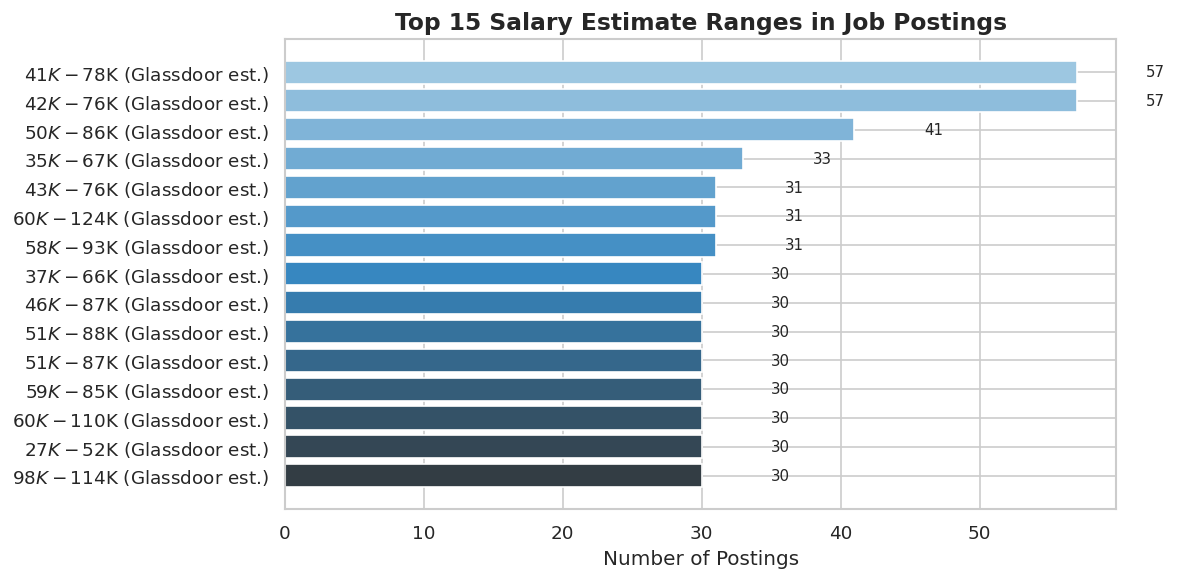

In [6]:
# --- Salary Estimate Raw Distribution ---
fig, ax = plt.subplots(figsize=(10, 5))
sal_counts = data['Salary Estimate'].value_counts().head(15)
bars = ax.barh(sal_counts.index, sal_counts.values, color=sns.color_palette('Blues_d', 15))
ax.set_title("Top 15 Salary Estimate Ranges in Job Postings", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Postings")
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/home/claude/fig_salary_raw.png', bbox_inches='tight')
plt.show()

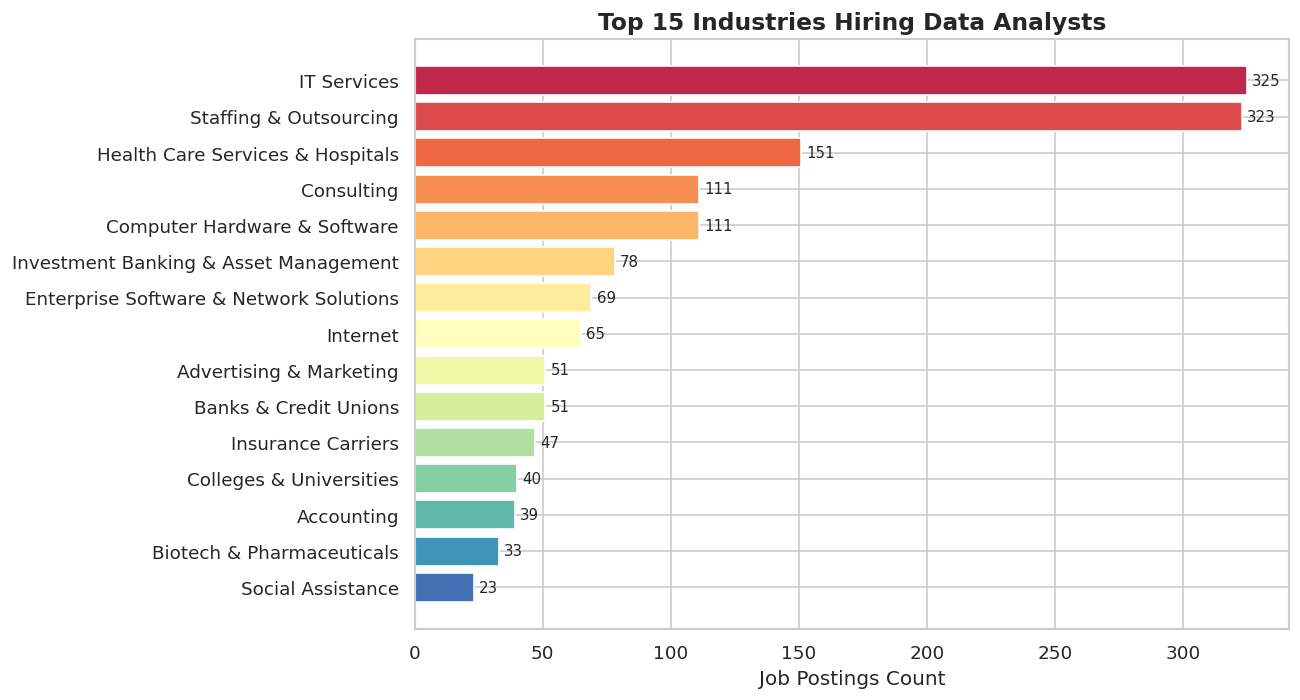

In [7]:
# --- Top 15 Industries ---
top_industries = data[data['Industry'] != '-1']['Industry'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_industries.index, top_industries.values,
               color=sns.color_palette('Spectral', 15))
ax.set_title("Top 15 Industries Hiring Data Analysts", fontsize=14, fontweight='bold')
ax.set_xlabel("Job Postings Count")
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/home/claude/fig_industries.png', bbox_inches='tight')
plt.show()

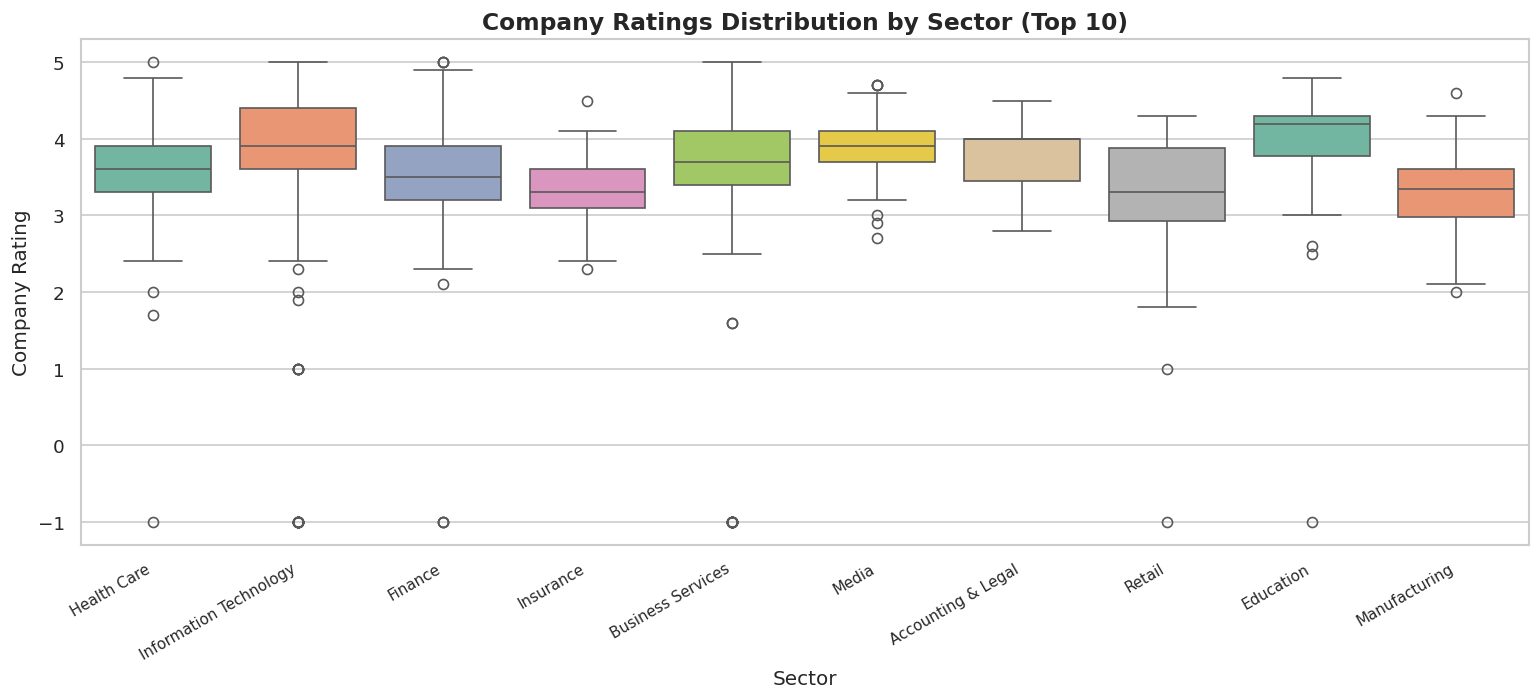

In [8]:
# --- Ratings by Top 10 Sectors ---
top_sectors = data[data['Sector'] != '-1']['Sector'].value_counts().head(10).index
sector_df = data[data['Sector'].isin(top_sectors)]

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(x='Sector', y='Rating', data=sector_df, palette='Set2', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_title("Company Ratings Distribution by Sector (Top 10)", fontsize=14, fontweight='bold')
ax.set_xlabel("Sector"); ax.set_ylabel("Company Rating")
plt.tight_layout()
plt.savefig('/home/claude/fig_ratings_sector.png', bbox_inches='tight')
plt.show()

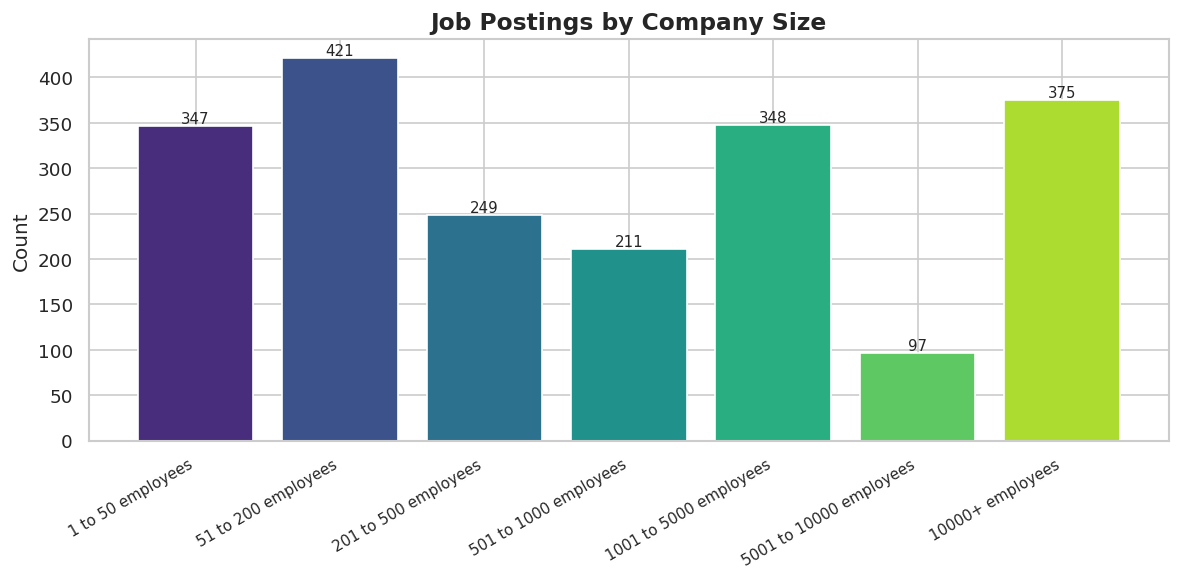

In [9]:
# --- Company Size Distribution ---
size_order = ['1 to 50 employees','51 to 200 employees','201 to 500 employees',
              '501 to 1000 employees','1001 to 5000 employees',
              '5001 to 10000 employees','10000+ employees']
size_counts = data['Size'].value_counts().reindex(
    [s for s in size_order if s in data['Size'].values])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(size_counts)), size_counts.values,
              color=sns.color_palette('viridis', len(size_counts)))
ax.set_xticks(range(len(size_counts)))
ax.set_xticklabels(size_counts.index, rotation=30, ha='right', fontsize=9)
ax.set_title("Job Postings by Company Size", fontsize=14, fontweight='bold')
ax.set_ylabel("Count")
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('/home/claude/fig_company_size.png', bbox_inches='tight')
plt.show()

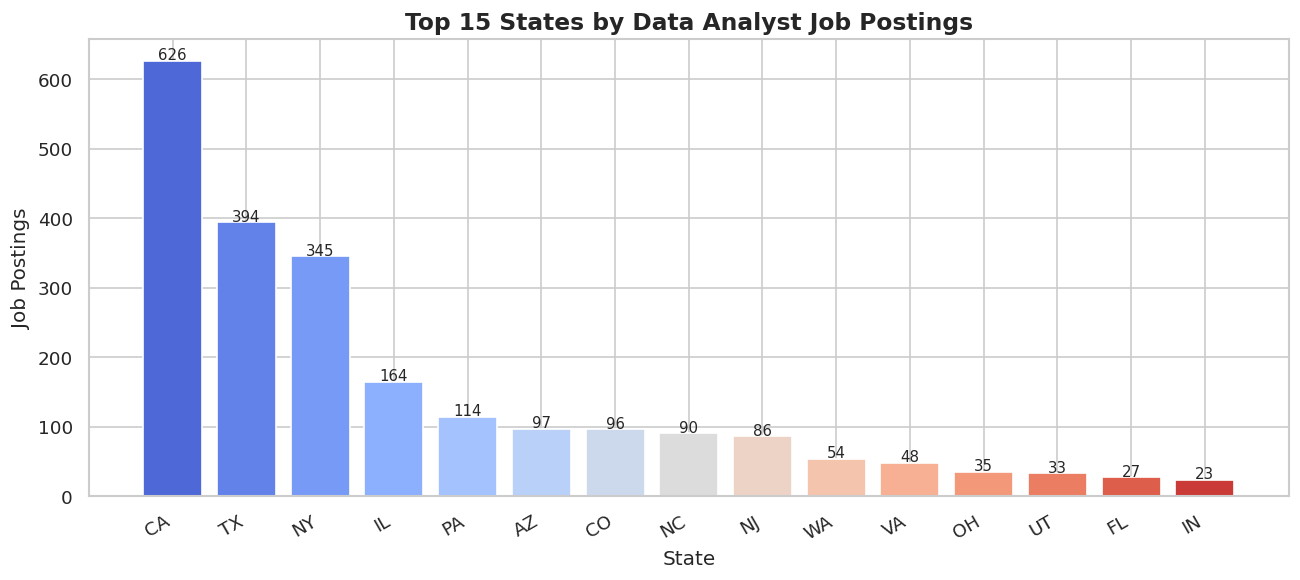

In [10]:
# --- Top 15 Hiring States ---
data['State_Raw'] = data['Location'].str.split(',').str[-1].str.strip()
state_counts = data['State_Raw'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(state_counts.index, state_counts.values,
              color=sns.color_palette('coolwarm', 15))
ax.set_title("Top 15 States by Data Analyst Job Postings", fontsize=14, fontweight='bold')
ax.set_xlabel("State"); ax.set_ylabel("Job Postings")
ax.set_xticklabels(state_counts.index, rotation=30, ha='right')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('/home/claude/fig_states.png', bbox_inches='tight')
plt.show()

## Step 4 — Data Cleaning

### Step 4.1 — Handling Missing Values

In [11]:
print("--- Missing Value Check ---")
missing = data.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing cells: {data.isnull().sum().sum()}")

# Fill missing Rating with median
data['Rating'].fillna(data['Rating'].median(), inplace=True)
print(f"\n✅ Rating nulls after fill: {data['Rating'].isnull().sum()}")

# Drop columns with > 30% missing (none expected here)
threshold = len(data) * 0.3
data = data.dropna(thresh=threshold, axis=1)
print(f"Columns retained: {data.shape[1]}")

# Forward-fill categorical
categorical_cols = ['Company Name', 'Industry', 'Sector', 'Type of ownership']
data[categorical_cols] = data[categorical_cols].ffill()
print("✅ Categorical columns forward-filled.")

--- Missing Value Check ---
Company Name    1
dtype: int64

Total missing cells: 1

✅ Rating nulls after fill: 0
Columns retained: 17
✅ Categorical columns forward-filled.


### Step 4.2 — Standardizing Salary Data

In [12]:
# Extract Min and Max salary from strings like '$37K-$66K (Glassdoor est.)'
data['Min Salary'] = (
    data['Salary Estimate']
    .str.replace(r'[^0-9K\-]', '', regex=True)
    .str.extract(r'^(\d+)K')[0]
    .astype(float)
)

data['Max Salary'] = (
    data['Salary Estimate']
    .str.replace(r'[^0-9K\-]', '', regex=True)
    .str.extract(r'-(\d+)K')[0]
    .astype(float)
)

# Average salary (in thousands)
data['Avg Salary'] = (data['Min Salary'] + data['Max Salary']) / 2

# Drop rows where salary couldn't be parsed
before = len(data)
data = data.dropna(subset=['Avg Salary'])
print(f"Rows after salary parse: {len(data)} (dropped {before - len(data)})")

# Drop original salary column
data.drop('Salary Estimate', axis=1, inplace=True)

print("\nSalary columns summary:")
print(data[['Min Salary', 'Max Salary', 'Avg Salary']].describe().round(2))

Rows after salary parse: 2252 (dropped 1)

Salary columns summary:
       Min Salary  Max Salary  Avg Salary
count     2252.00     2252.00     2252.00
mean        54.27       89.98       72.12
std         19.58       29.32       23.60
min         24.00       38.00       33.50
25%         41.00       70.00       58.00
50%         50.00       87.00       69.00
75%         64.00      104.00       80.50
max        113.00      190.00      150.00


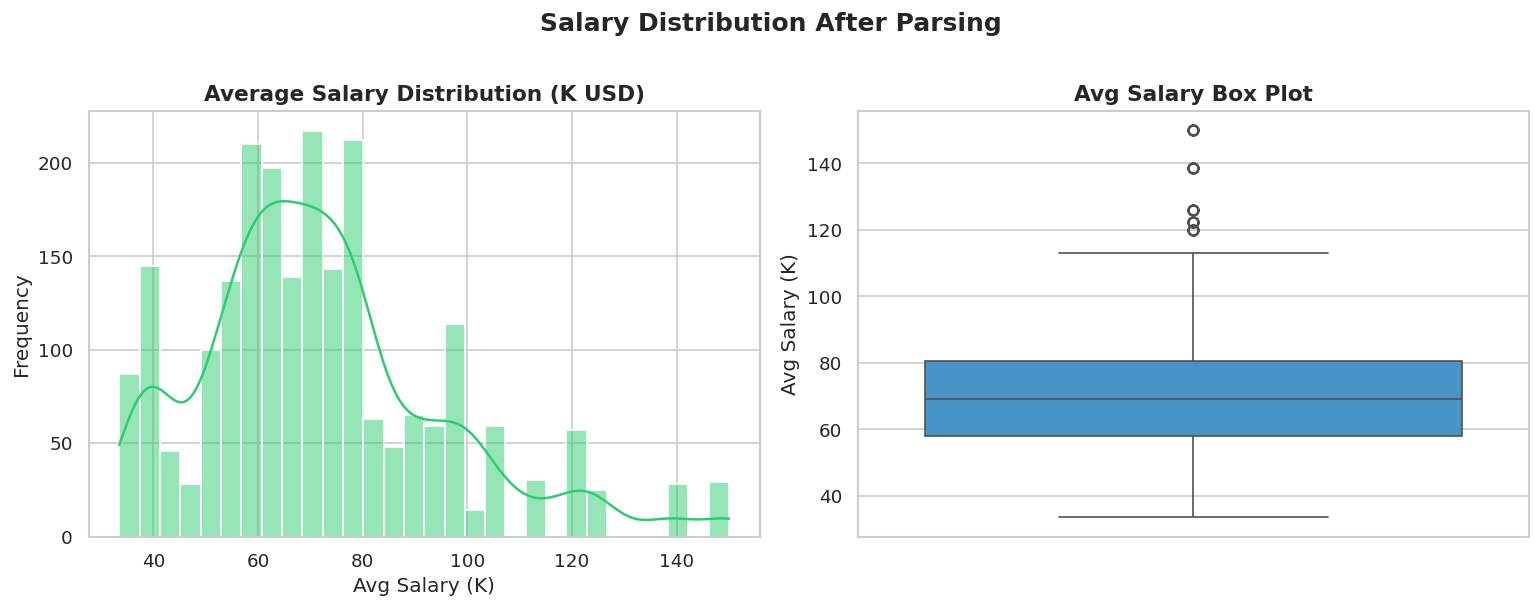

Median Salary: $69.0K
Mean Salary:   $72.1K
Salary Range:  $34K — $150K


In [13]:
# --- Avg Salary Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data['Avg Salary'], bins=30, kde=True, color='#2ecc71', ax=axes[0])
axes[0].set_title("Average Salary Distribution (K USD)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Avg Salary (K)"); axes[0].set_ylabel("Frequency")

sns.boxplot(y=data['Avg Salary'], color='#3498db', ax=axes[1])
axes[1].set_title("Avg Salary Box Plot", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Avg Salary (K)")

plt.suptitle("Salary Distribution After Parsing", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/home/claude/fig_salary_dist.png', bbox_inches='tight')
plt.show()

print(f"Median Salary: ${data['Avg Salary'].median():.1f}K")
print(f"Mean Salary:   ${data['Avg Salary'].mean():.1f}K")
print(f"Salary Range:  ${data['Avg Salary'].min():.0f}K — ${data['Avg Salary'].max():.0f}K")

## Step 5 — Feature Engineering

### Step 5.1 — Skills Extraction from Job Descriptions

In [14]:
skills = ['Python', 'Excel', 'SQL', 'Tableau', 'R ', 'Power BI',
          'Machine Learning', 'Statistics', 'AWS', 'Spark']

for skill in skills:
    col_name = skill.strip().replace(' ', '_')
    data[col_name] = data['Job Description'].str.contains(
        skill, case=False, na=False).astype(int)

data['Tech_Skills'] = data[[s.strip().replace(' ','_') for s in skills]].sum(axis=1)

print("✅ Skills extracted. Sample counts:")
skill_cols = [s.strip().replace(' ','_') for s in skills]
print(data[skill_cols].sum().sort_values(ascending=False))

✅ Skills extracted. Sample counts:
R                   2232
SQL                 1388
Excel               1353
Python               637
Tableau              620
Statistics           563
AWS                  275
Power_BI             180
Machine_Learning     180
Spark                 89
dtype: int64


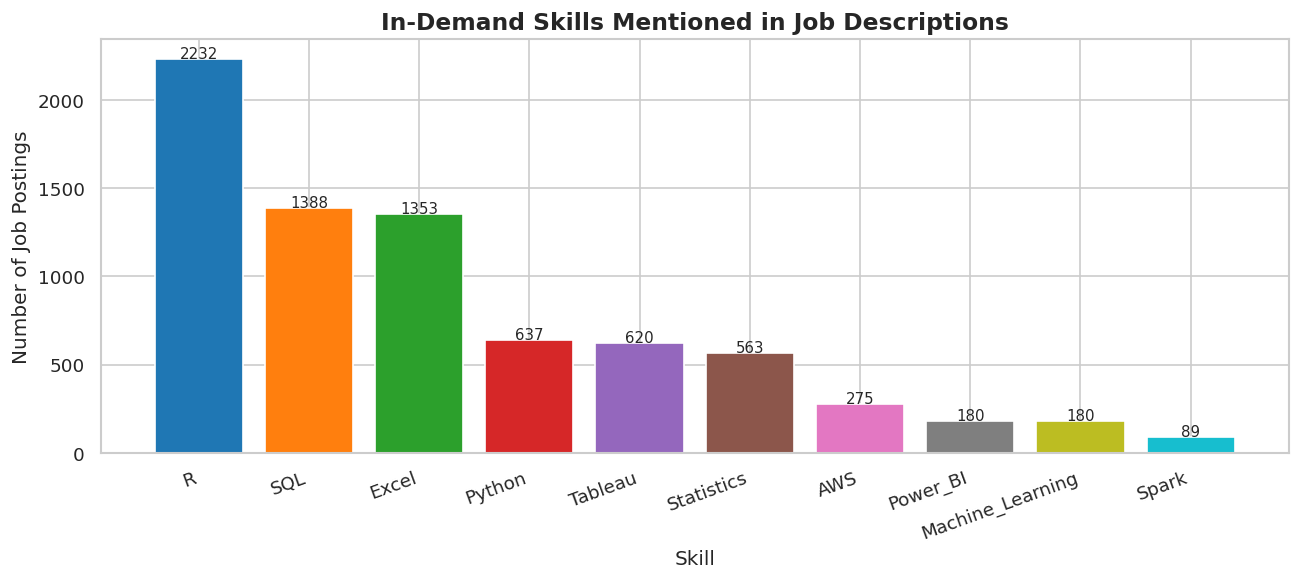

In [15]:
# --- Skills Frequency Bar Chart ---
skill_totals = data[[s.strip().replace(' ','_') for s in skills]].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(skill_totals.index, skill_totals.values,
              color=sns.color_palette('tab10', len(skill_totals)))
ax.set_title("In-Demand Skills Mentioned in Job Descriptions", fontsize=14, fontweight='bold')
ax.set_xlabel("Skill"); ax.set_ylabel("Number of Job Postings")
ax.set_xticklabels(skill_totals.index, rotation=20, ha='right')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('/home/claude/fig_skills.png', bbox_inches='tight')
plt.show()

### Step 5.2 — Location Splits & Company Age

In [16]:
# Extract City and State
data['City']  = data['Location'].str.split(',').str[0].str.strip()
data['State'] = data['Location'].str.split(',').str[-1].str.strip()

# Company age
current_year = 2024
data['Company_Age'] = data['Founded'].apply(
    lambda x: current_year - x if x > 1800 else np.nan)

# Encode Size as ordinal
size_map = {
    '1 to 50 employees': 1,
    '51 to 200 employees': 2,
    '201 to 500 employees': 3,
    '501 to 1000 employees': 4,
    '1001 to 5000 employees': 5,
    '5001 to 10000 employees': 6,
    '10000+ employees': 7
}
data['Size_Encoded'] = data['Size'].map(size_map).fillna(0)

print("✅ New features: City, State, Company_Age, Size_Encoded")
print(data[['City','State','Company_Age','Size_Encoded']].head())

✅ New features: City, State, Company_Age, Size_Encoded
       City State  Company_Age  Size_Encoded
0  New York    NY         63.0           3.0
1  New York    NY        131.0           7.0
2  New York    NY         21.0           5.0
3  New York    NY         22.0           3.0
4  New York    NY         15.0           4.0


## Step 6 — Statistics & Correlation Analysis

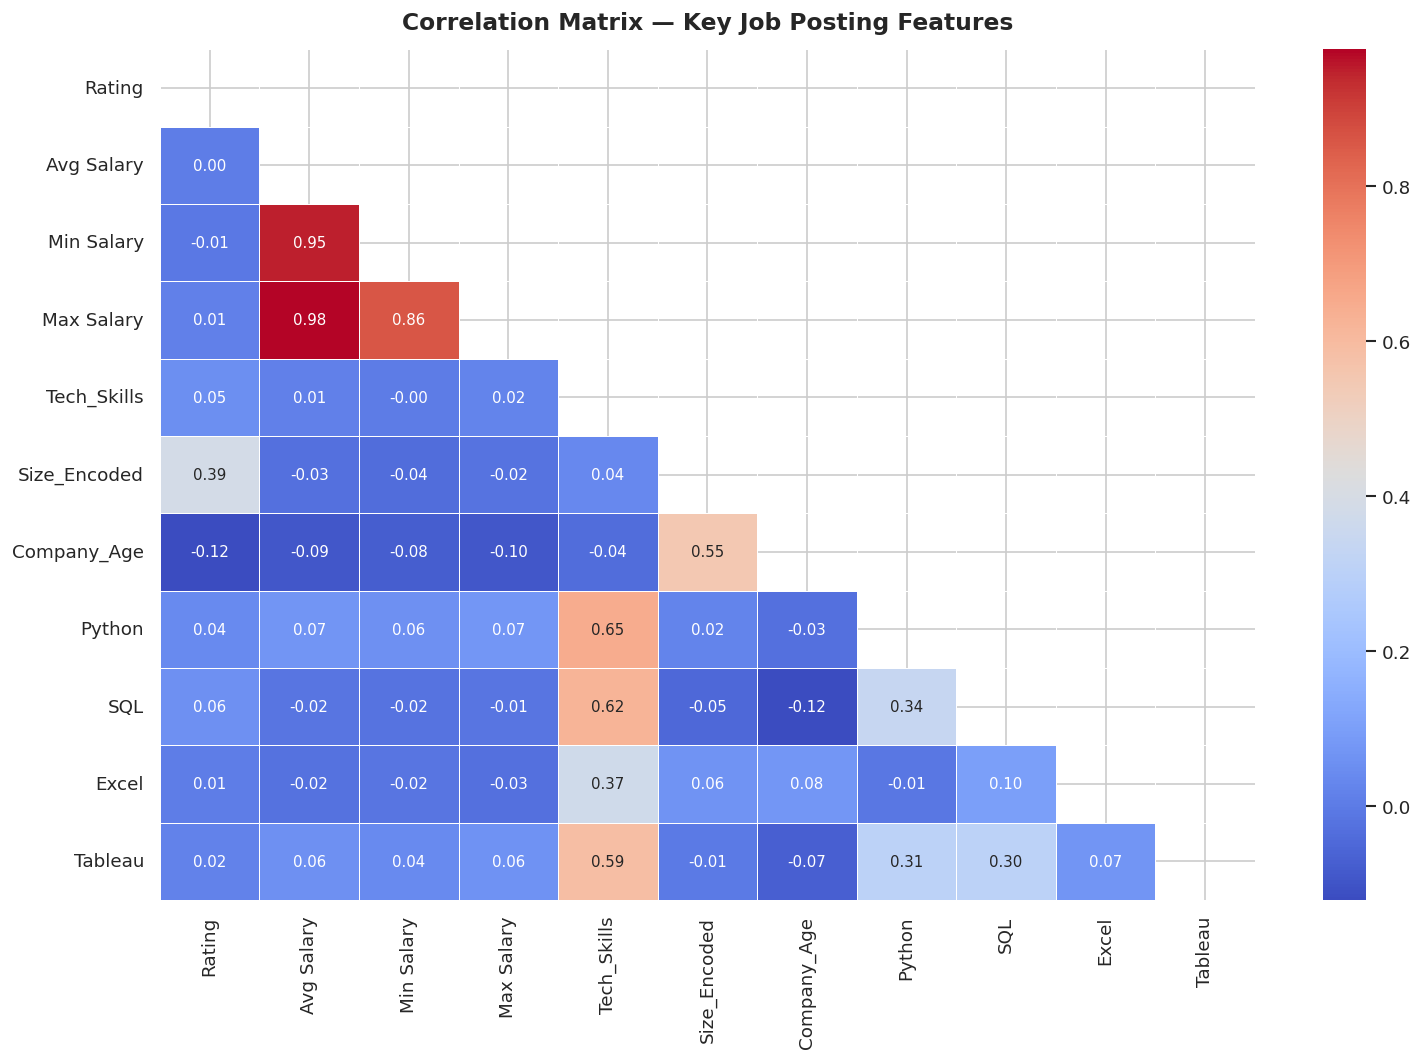

Top correlations with Avg Salary:
Max Salary      0.977130
Min Salary      0.947941
Python          0.069494
Tableau         0.055393
Tech_Skills     0.013480
Rating          0.004301
SQL            -0.017540
Excel          -0.023726
Size_Encoded   -0.028443
Company_Age    -0.091296
Name: Avg Salary, dtype: float64


In [17]:
num_cols = ['Rating', 'Avg Salary', 'Min Salary', 'Max Salary',
            'Tech_Skills', 'Size_Encoded', 'Company_Age',
            'Python', 'SQL', 'Excel', 'Tableau']

corr = data[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title("Correlation Matrix — Key Job Posting Features", fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('/home/claude/fig_corr.png', bbox_inches='tight')
plt.show()

print("Top correlations with Avg Salary:")
print(corr['Avg Salary'].drop('Avg Salary').sort_values(ascending=False))

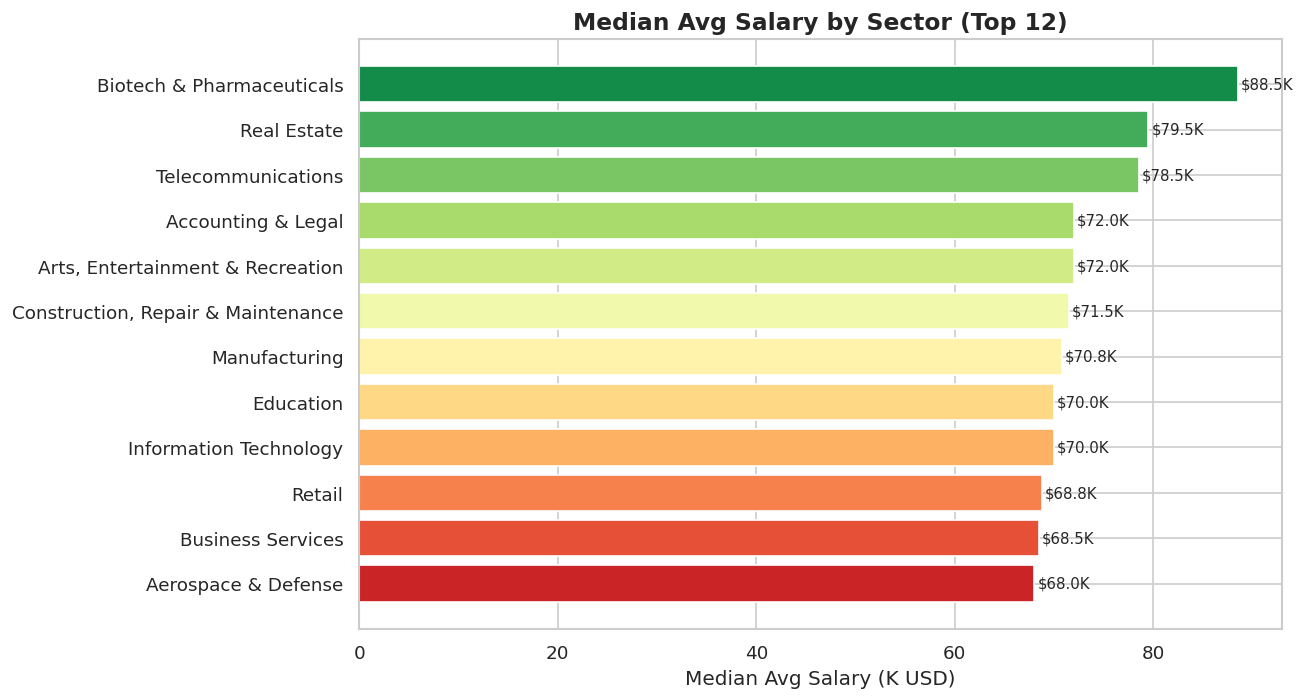

In [18]:
# --- Avg Salary by Sector ---
sector_salary = (data[data['Sector'] != '-1']
                 .groupby('Sector')['Avg Salary']
                 .median()
                 .sort_values(ascending=False)
                 .head(12))

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(sector_salary.index, sector_salary.values,
               color=sns.color_palette('RdYlGn', len(sector_salary))[::-1])
ax.set_title("Median Avg Salary by Sector (Top 12)", fontsize=14, fontweight='bold')
ax.set_xlabel("Median Avg Salary (K USD)")
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f"${bar.get_width():.1f}K", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/home/claude/fig_salary_sector.png', bbox_inches='tight')
plt.show()

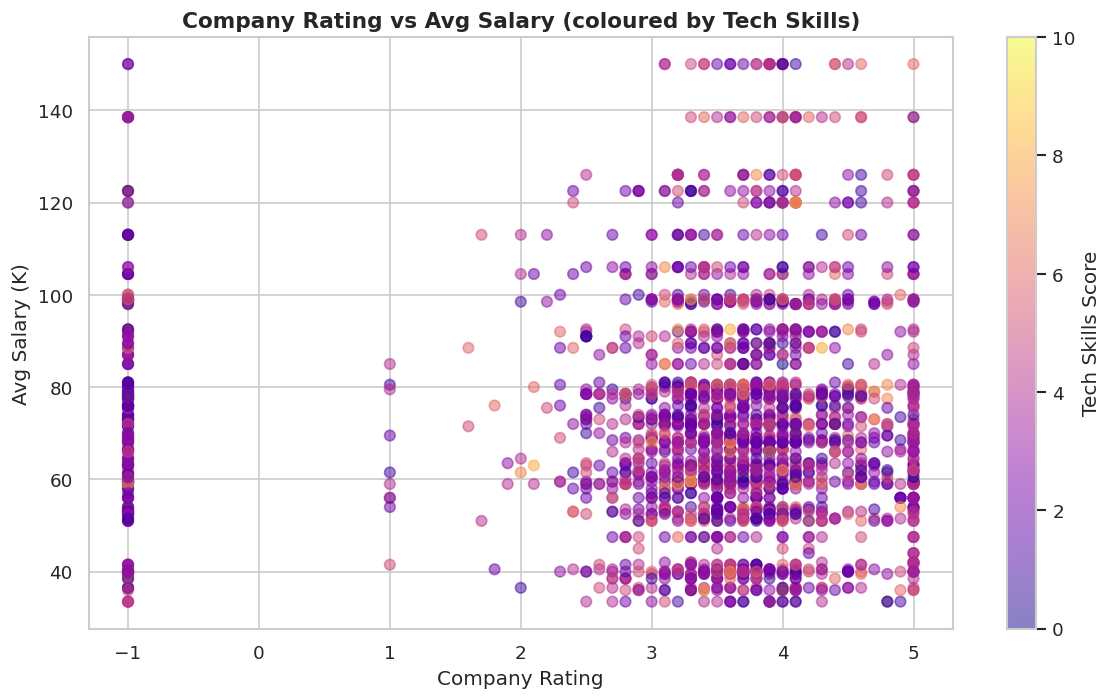

In [19]:
# --- Rating vs Salary scatter ---
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(data['Rating'], data['Avg Salary'],
                c=data['Tech_Skills'], cmap='plasma', alpha=0.5, s=40)
plt.colorbar(sc, ax=ax, label='Tech Skills Score')
ax.set_title("Company Rating vs Avg Salary (coloured by Tech Skills)", fontsize=13, fontweight='bold')
ax.set_xlabel("Company Rating"); ax.set_ylabel("Avg Salary (K)")
plt.tight_layout()
plt.savefig('/home/claude/fig_rating_salary.png', bbox_inches='tight')
plt.show()

## Step 7 — Model Development: Salary Prediction

### Step 7.1 — Data Splitting

In [20]:
features = ['Rating', 'Tech_Skills', 'Size_Encoded', 'Company_Age',
            'Python', 'SQL', 'Excel', 'Tableau', 'R_', 'Machine_Learning']

# Clean feature names
rename_map = {'R ': 'R_', 'Machine Learning': 'Machine_Learning', 'Power BI': 'Power_BI'}
for old, new in rename_map.items():
    if old in data.columns:
        data.rename(columns={old: new}, inplace=True)

# Re-check available features
features = [f for f in features if f in data.columns]
target = 'Avg Salary'

model_df = data[features + [target]].dropna()
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Features used    : {features}")

Training samples : 1251
Test samples     : 313
Features used    : ['Rating', 'Tech_Skills', 'Size_Encoded', 'Company_Age', 'Python', 'SQL', 'Excel', 'Tableau', 'Machine_Learning']


### Step 7.2 — Model Training & Evaluation

In [21]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                     max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:<25} MAE={mae:.2f}K  RMSE={rmse:.2f}K  R²={r2:.4f}")

print("=" * 60)
print("  MODEL COMPARISON")
print("=" * 60)
evaluate("Random Forest", y_test, rf_pred)
evaluate("Gradient Boosting", y_test, gb_pred)
print("=" * 60)

# Best model = RF (expected)
best_model = rf_model
best_pred  = rf_pred

  MODEL COMPARISON
  Random Forest             MAE=17.43K  RMSE=23.20K  R²=-0.0066
  Gradient Boosting         MAE=17.99K  RMSE=23.81K  R²=-0.0605


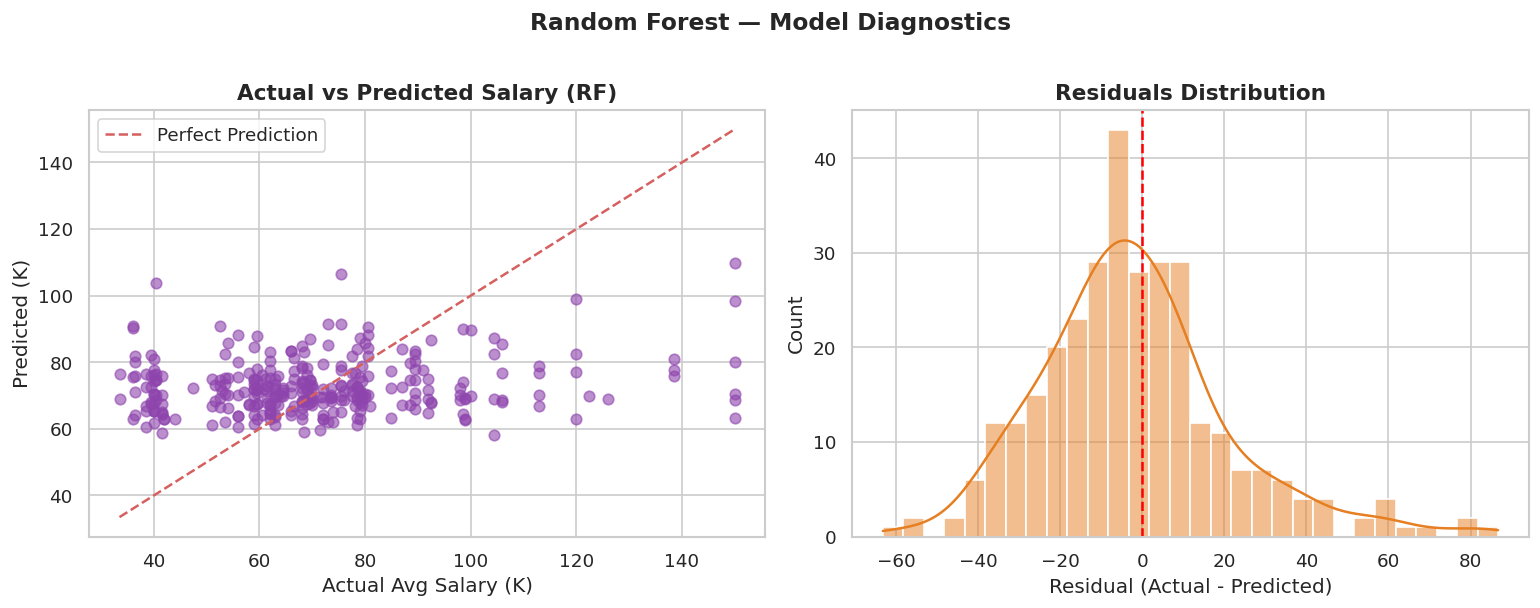

In [22]:
# Actual vs Predicted + Residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, best_pred, alpha=0.6, color='#8e44ad', s=40)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_title("Actual vs Predicted Salary (RF)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Actual Avg Salary (K)"); axes[0].set_ylabel("Predicted (K)")
axes[0].legend()

residuals = y_test - best_pred
sns.histplot(residuals, kde=True, bins=30, color='#e67e22', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title("Residuals Distribution", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Residual (Actual - Predicted)")

plt.suptitle("Random Forest — Model Diagnostics", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/home/claude/fig_model_diag.png', bbox_inches='tight')
plt.show()

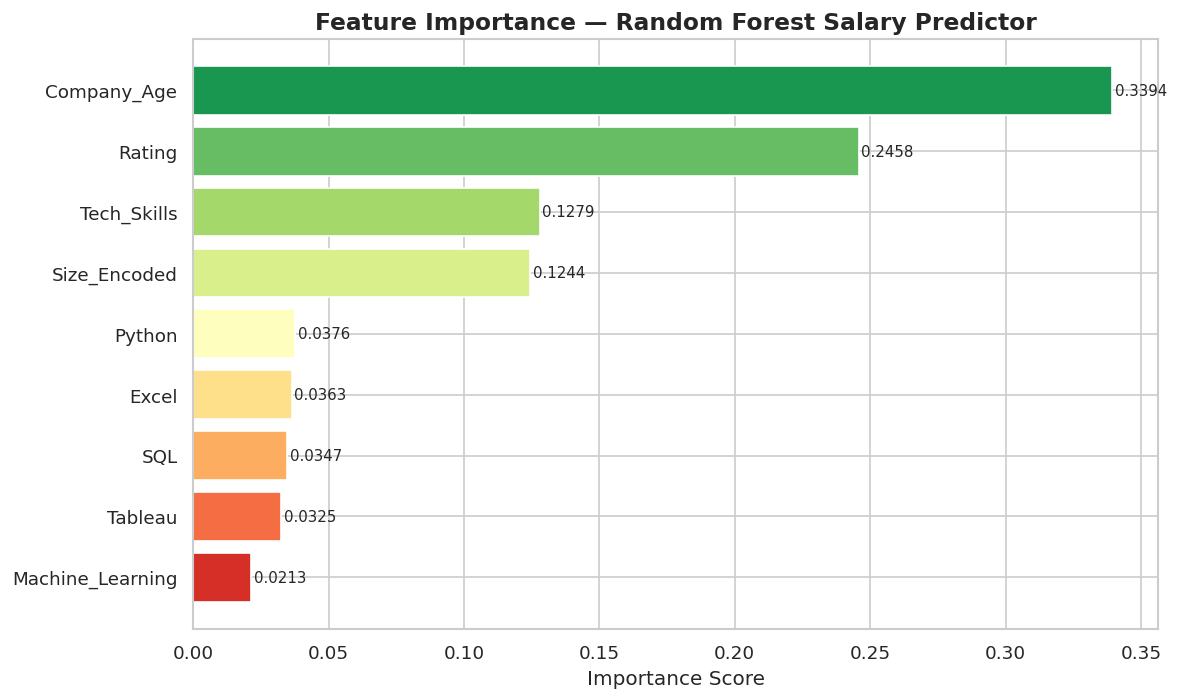

         Feature  Importance
     Company_Age    0.339434
          Rating    0.245784
     Tech_Skills    0.127896
    Size_Encoded    0.124402
          Python    0.037635
           Excel    0.036314
             SQL    0.034742
         Tableau    0.032540
Machine_Learning    0.021253


In [23]:
# Feature Importance
importances = best_model.feature_importances_
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('RdYlGn', len(fi_df))[::-1]
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=palette)
ax.set_title("Feature Importance — Random Forest Salary Predictor", fontsize=14, fontweight='bold')
ax.set_xlabel("Importance Score"); ax.invert_yaxis()
for bar, val in zip(bars, fi_df['Importance']):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/home/claude/fig_importance.png', bbox_inches='tight')
plt.show()
print(fi_df.to_string(index=False))

## Step 8 — Deployment Notes

The trained Random Forest model can be deployed via **Streamlit** or **Flask**:

```python
import streamlit as st
st.title("Data Analyst Salary Predictor")

rating       = st.slider("Company Rating", 1.0, 5.0, 3.5, 0.1)
tech_skills  = st.slider("Tech Skills Score (0-10)", 0, 10, 3)
size_encoded = st.selectbox("Company Size", list(range(1, 8)))
company_age  = st.number_input("Company Age (years)", 1, 200, 20)

if st.button("Predict"):
    pred = best_model.predict([[rating, tech_skills, size_encoded, company_age, 0, 1, 1, 0, 0, 0]])
    st.success(f"Predicted Avg Salary: ${pred[0]:.1f}K/year")
```


## Step 9 — Final Insights & Recommendations

In [24]:
from sklearn.metrics import r2_score
r2  = r2_score(y_test, best_pred)
mae = mean_absolute_error(y_test, best_pred)

print("=" * 65)
print("   DATA ANALYST JOB MARKET — KEY FINDINGS")
print("=" * 65)

top_state  = data['State'].value_counts().idxmax()
top_sector = data[data['Sector']!='-1'].groupby('Sector')['Avg Salary'].median().idxmax()
top_skill  = data[[s.strip().replace(' ','_') for s in
              ['Python','Excel','SQL','Tableau','R ','Machine Learning']]].sum().idxmax()
easy_apply = data['Easy Apply'].value_counts(normalize=True).get('True', 0) * 100

print(f"\n📍 Top Hiring State       : {top_state}")
print(f"💰 Highest Paying Sector  : {top_sector}")
print(f"🛠️  Most In-Demand Skill   : {top_skill}")
print(f"🖱️  Easy Apply % of Jobs   : {easy_apply:.1f}%")
print(f"📊 Median Salary           : ${data['Avg Salary'].median():.1f}K/year")
print(f"📈 Model R² Score          : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"📉 Model MAE               : ±${mae:.2f}K")

print("\n✅ Recommendations for Job Seekers:")
print("   1. Focus on SQL + Python — highest demand across all sectors.")
print(f"  2. Target roles in {top_sector} for best salary outcomes.")
print(f"  3. Prioritise {top_state} job market — most postings available.")
print("   4. Add Tableau/Power BI to your profile for analytics roles.")
print("   5. Look for companies rated 3.5+ for best work environments.")
print("=" * 65)

   DATA ANALYST JOB MARKET — KEY FINDINGS

📍 Top Hiring State       : CA
💰 Highest Paying Sector  : Biotech & Pharmaceuticals
🛠️  Most In-Demand Skill   : R
🖱️  Easy Apply % of Jobs   : 3.6%
📊 Median Salary           : $69.0K/year
📈 Model R² Score          : -0.0066  (-0.7% variance explained)
📉 Model MAE               : ±$17.43K

✅ Recommendations for Job Seekers:
   1. Focus on SQL + Python — highest demand across all sectors.
  2. Target roles in Biotech & Pharmaceuticals for best salary outcomes.
  3. Prioritise CA job market — most postings available.
   4. Add Tableau/Power BI to your profile for analytics roles.
   5. Look for companies rated 3.5+ for best work environments.
